<H1>MACHINE LEARNING</H1>

<H3>TYPES</H3>

<pre>1)Supervised Learning
    1)Regression<pre>
        1)Linear Regression
        2)Polynomial Regression
        3)Lasso Regression
        4)Rigid Regression
    2)Classification<pre>
        1)Logistic Regression
        2)Naive Bayes
        3)KNN: K Nearest Neighbors
        4)SVM: Support Vector Machine</pre>


<h3>MACHINE LEARNING PROCEDURE</H3>
<PRE>    Step 1: Data Reading
    Step 2: Data Cleaning
    Step 3: Data analysis
    Step 4: Encoding
    Step 5: I/O Creation
    Step 6: Train-Test-Split
    Step 7: Standard Scalar Transform
    Step 8: Machine Learning Model
    step 9: Prediction
    Step 10:Accuracy</pre>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ad=pd.read_csv(r"C:\Users\mishr\OneDrive\Desktop\advertising.csv")
ad

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


Input and Output

In [5]:
# Input Columns (Features):
# These are the independent variables used to predict the output.
# Syntax:
# ip = dataframe.drop('output_column_name', axis=1)
ip=ad.drop('Sales',axis=1)
ip

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [4]:
ip.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [ ]:
# Output Column (Target Variable):
# This is the dependent variable that the machine learning model tries to predict.
# Syntax:
# op = dataframe.output_column_name
op=ad.Sales
op

0      22.1
1      10.4
2      12.0
3      16.5
4      17.9
       ... 
195     7.6
196    14.0
197    14.8
198    25.5
199    18.4
Name: Sales, Length: 200, dtype: float64

In [5]:
op.head()

0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64

In [3]:
import sklearn
print(sklearn.__version__)

1.7.2


In [ ]:
# Train-Test Split:
# Divides the dataset into training and testing sets.

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    ip,
    op,
    train_size=0.8,# Allocates 80% of the data for training.Remaining 20% is automatically used for testing.
    random_state=3000# Ensures the same random split is generated every time the code is executed, making results reproducible.
)

In [ ]:
x_train  # Input features used to train the model.

,TV,Radio,Newspaper
83,68.4,44.5,35.6
180,156.6,2.6,8.3
170,50.0,11.6,18.4
57,136.2,19.2,16.6
49,66.9,11.7,36.8
...,...,...,...
26,142.9,29.3,12.6
181,218.5,5.4,27.4
174,222.4,3.4,13.1
1,44.5,39.3,45.1


In [13]:
y_train
# Output values used to train the model.

83     13.6
180    15.5
170     8.4
57     13.2
49      9.7
       ... 
26     15.0
181    17.2
174    16.5
1      10.4
51     10.7
Name: Sales, Length: 160, dtype: float64

In [12]:
x_test
# Input features used to test the model.


,TV,Radio,Newspaper
85,193.2,18.4,65.7
171,164.5,20.9,47.4
147,243.2,49.0,44.3
112,175.7,15.4,2.4
46,89.7,9.9,35.7
82,75.3,20.3,32.5
93,250.9,36.5,72.3
4,180.8,10.8,58.4
120,141.3,26.8,46.2
127,80.2,0.0,9.2


In [14]:
y_test
# Actual output values used to evaluate the model.


85     20.2
171    17.5
147    25.4
112    17.1
46     10.6
82     11.3
93     22.2
4      17.9
120    15.5
127    11.9
81     17.3
118    15.9
34     11.9
41     17.1
77     14.2
72      8.8
67     13.4
58     23.8
9      15.6
13     13.7
148    10.9
54     20.2
108     5.3
152    16.6
36     25.4
92     19.4
141    19.2
160    16.4
123    15.2
69     22.3
142    20.1
38     10.1
140    10.9
192     5.9
22      5.6
164    11.9
37     14.7
75      8.7
44      8.5
184    17.6
Name: Sales, dtype: float64

In [9]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(160, 3)
(160,)
(40, 3)
(40,)


In [19]:

from sklearn.preprocessing import StandardScaler

sc = StandardScaler() #Standardizes features by transforming them to have:1) Mean=0 2) Standard Deviation = 1

x_train = sc.fit_transform(x_train) # transform():Uses the learned mean and standard deviation to scale the data.

x_test = sc.fit(x_test) #fit():Learns the mean and standard deviation from the data.
# fit_transform():
# Combines fit() and transform() in a single step.

# Testing Data
# Only transform using training data statistics
#x_test = sc.transform(x_test)

In [20]:
x_train

array([[-0.92463483,  1.44412994,  0.26997394],
       [ 0.0884748 , -1.36975343, -0.99844184],
       [-1.1359865 , -0.76533934, -0.52917447],
       [-0.14584988, -0.25494522, -0.61280628],
       [-0.94186459, -0.75862363,  0.32572848],
       [-1.4231491 , -0.80563361, -0.00415255],
       [ 0.01036657, -1.45705769, -0.25504798],
       [ 0.95570583, -0.9668107 , -0.979857  ],
       [ 0.2573264 ,  1.12177576,  0.36754438],
       [ 1.52199046,  1.11506005,  1.20850869],
       [-0.62828304, -1.21529205, -1.00773427],
       [ 0.66624593, -0.98024213, -0.15747754],
       [-1.09578374, -1.4100477 , -0.38978812],
       [-0.70868856, -0.75190792, -0.18070859],
       [ 0.76388121,  0.04054611,  1.2921405 ],
       [ 1.04759786, -1.05411496, -0.979857  ],
       [ 0.41354285, -0.1340624 , -0.36191085],
       [ 0.38712389,  1.55829705,  1.34324883],
       [-0.67193175, -1.52421481, -0.30615631],
       [ 1.43354438,  0.39647885,  1.38971094],
       [-0.01834969,  0.06069325, -0.496

In [21]:
y_test

85     20.2
171    17.5
147    25.4
112    17.1
46     10.6
82     11.3
93     22.2
4      17.9
120    15.5
127    11.9
81     17.3
118    15.9
34     11.9
41     17.1
77     14.2
72      8.8
67     13.4
58     23.8
9      15.6
13     13.7
148    10.9
54     20.2
108     5.3
152    16.6
36     25.4
92     19.4
141    19.2
160    16.4
123    15.2
69     22.3
142    20.1
38     10.1
140    10.9
192     5.9
22      5.6
164    11.9
37     14.7
75      8.7
44      8.5
184    17.6
Name: Sales, dtype: float64

In [22]:
print(type(x_train))
print(type(x_test))

<class 'numpy.ndarray'>
<class 'sklearn.preprocessing._data.StandardScaler'>


In [25]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler() # MinMaxScaler:Scales all feature values to a fixed range,usually between 0 and 1.

x_train = mm.fit_transform(x_train)
x_test = mm.transform(x_test)
print(type(x_train))
print(type(x_test))
print(x_test)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[[ 0.65099763  0.36863544  0.57519789]
 [ 0.5539398   0.41955193  0.41424802]
 [ 0.82008793  0.99185336  0.38698329]
 [ 0.59181603  0.30753564  0.01846966]
 [ 0.30098072  0.19551935  0.31134565]
 [ 0.25228272  0.40733198  0.28320141]
 [ 0.84612783  0.73727088  0.63324538]
 [ 0.60906324  0.21384929  0.51099384]
 [ 0.47548191  0.53971487  0.40369393]
 [ 0.26885357 -0.00610998  0.07827617]
 [ 0.80858979  0.07739308  0.32189974]
 [ 0.42272574  0.74541752  0.6939314 ]
 [ 0.32127156  0.02240326  0.06244503]
 [ 0.59621238  0.67413442  0.33773087]
 [ 0.40514034  0.57433809  0.12225154]
 [ 0.08826513  0.66598778  0.16710642]
 [ 0.4687183   0.2892057   0.08707124]
 [ 0.71051742  1.00407332  0.3289358 ]
 [ 0.67331755  0.04684318  0.18381706]
 [ 0.32735881  0.14867617  0.06068602]
 [ 0.12614136  0.81466395  0.10202287]
 [ 0.88603314  0.58044807  0.13720317]
 [ 0.04193439  0.00203666  0.22251539]
 [ 0.66587758  0.46843177  0.12225154]
 [ 0.90023673  0

MACHINE LEARNING MODEL

Linear regression: It is a supervised machine learning algorithm used to model the relationship between one dependent variable (target/output) and one or more independent variables (features/inputs) by fitting the best possible straight line through the data.


In [ ]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()


lr.fit(x_train,y_train) # Train the model using training data fit() learns the relationship between inputs (x_train) and outputs (y_train)
pred=lr.predict(x_test) #predict() generates predicted values using the trained model
pred


array([17.05693484, 15.75641312, 23.05413049, 15.74744579, 10.50238322,
       10.8374596 , 22.14315186, 15.56126901, 15.13028418,  8.9058519 ,
       18.03331122, 15.38843188,  9.89755238, 17.77574275, 14.16507388,
        9.56183918, 13.67753382, 21.35477337, 15.68991585, 10.66243896,
       10.95168478, 21.92355689,  5.31289608, 17.79405246, 23.75976475,
       20.00911687, 18.91917067, 15.88022456, 14.96175202, 21.06136775,
       20.11697006,  9.77835622, 10.3679848 ,  5.93721567,  6.99998231,
       12.49571578, 13.94394958, 10.21527556,  8.69751809, 20.64094237])

In [ ]:
# Model Evaluation Metrics:
# Used to measure the performance and accuracy of the Linear Regression model.
from sklearn.metrics import mean_squared_error,r2_score
# Mean Squared Error (MSE): Measures the average squared difference between actual and predicted values; lower values indicate better performance.
mse=mean_squared_error(y_test,pred)
# R² Score: Measures how well the model explains the variance in the target variable; values closer to 1 indicate better performance.
r2=r2_score(y_test,pred)
print('MSE=',mse)
print('R2 score=',r2)

MSE= 2.0111402207104447
R2 score= 0.9245816996543246


In [ ]:
# Combines actual values (y_test) and predicted values (pred) into a single table for easy comparison and analysis.
df=pd.DataFrame({'Y_test':list(y_test),'Prediction':pred})
df

,Y_test,Prediction
0,20.2,17.056935
1,17.5,15.756413
2,25.4,23.054130
3,17.1,15.747446
4,10.6,10.502383
5,11.3,10.837460
6,22.2,22.143152
7,17.9,15.561269
8,15.5,15.130284
9,11.9,8.905852


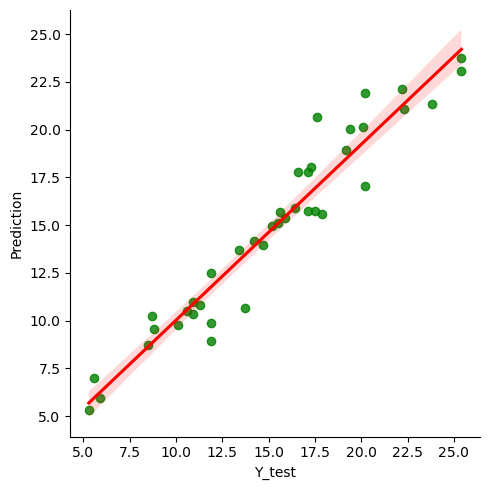

In [65]:
sns.lmplot(
    x='Y_test',
    y='Prediction',
    data=df,
    scatter_kws={'color':'g'},
    line_kws={'color':'r'}
)
plt.show()

MAINTAINANCE DATASET

In [8]:
mt=pd.read_csv(r"C:\Users\mishr\Downloads\maintenance_data.csv")
mt

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1
...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,TeamB,Provider4
996,88,1,116.727075,110.871332,95.075631,TeamA,Provider4
997,22,0,104.026778,88.212873,83.221220,TeamB,Provider1
998,78,0,104.911649,104.257296,83.421491,TeamA,Provider4


In [9]:
mt.isnull().sum()

lifetime          0
broken            0
pressureInd       0
moistureInd       0
temperatureInd    0
team              0
provider          0
dtype: int64

In [10]:
mt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   lifetime        1000 non-null   int64  
 1   broken          1000 non-null   int64  
 2   pressureInd     1000 non-null   float64
 3   moistureInd     1000 non-null   float64
 4   temperatureInd  1000 non-null   float64
 5   team            1000 non-null   object 
 6   provider        1000 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 54.8+ KB


In [11]:
mt.describe(include='all')

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,NaN,NaN,NaN,3,4
top,NaN,NaN,NaN,NaN,NaN,TeamB,Provider2
freq,NaN,NaN,NaN,NaN,NaN,356,266
mean,55.195000,0.397000,98.599338,99.376723,100.628541,NaN,NaN
std,26.472737,0.489521,19.964052,9.988726,19.633060,NaN,NaN
min,1.000000,0.000000,33.481917,58.547301,42.279598,NaN,NaN
25%,34.000000,0.000000,85.558076,92.771764,87.676913,NaN,NaN
50%,60.000000,0.000000,97.216997,99.433959,100.592277,NaN,NaN
75%,80.000000,1.000000,112.253190,106.120762,113.662885,NaN,NaN


<h3>Type of Encoding</h3> 
<pre>1)Label Encoding 
2)One-Hot Encoding
3)Ordinary Encoding
4)Frequency Encoding
5)Dummy Encoding
6)Target Encoding</pre>

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [13]:
mt.team=le.fit_transform(mt.team)
mt.team.unique()

array([0, 2, 1])

In [14]:
le.inverse_transform([0, 2, 1])

array(['TeamA', 'TeamC', 'TeamB'], dtype=object)

In [15]:
mt.provider=le.fit_transform(mt.provider)
mt.provider.unique()

array([3, 0, 1, 2])

In [16]:
le.inverse_transform([3, 0, 1, 2])

array(['Provider4', 'Provider1', 'Provider2', 'Provider3'], dtype=object)

In [78]:
c=mt.corr()
c

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
lifetime,1.000000,0.702656,0.000943,0.001196,0.001744,-0.046537,-0.025172
broken,0.702656,1.000000,-0.028942,-0.019520,0.015364,0.030876,-0.062972
pressureInd,0.000943,-0.028942,1.000000,0.020543,0.003641,-0.069528,-0.004337
moistureInd,0.001196,-0.019520,0.020543,1.000000,-0.009842,0.022420,0.028906
temperatureInd,0.001744,0.015364,0.003641,-0.009842,1.000000,0.007310,-0.010822
team,-0.046537,0.030876,-0.069528,0.022420,0.007310,1.000000,0.005606
provider,-0.025172,-0.062972,-0.004337,0.028906,-0.010822,0.005606,1.000000


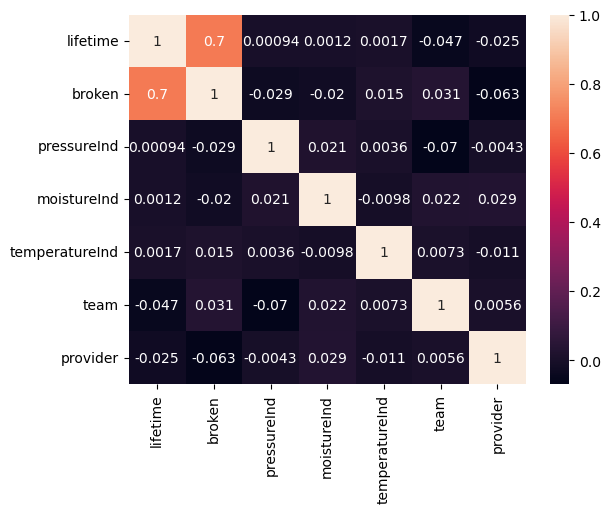

In [79]:
sns.heatmap(c,annot=True)
plt.show()

In [17]:
ip=mt.drop('broken',axis=1)
ip

,lifetime,pressureInd,moistureInd,temperatureInd,team,provider
0,56,92.178854,104.230204,96.517159,0,3
1,81,72.075938,103.065701,87.271062,2,3
2,60,96.272254,77.801376,112.196170,0,0
3,86,94.406461,108.493608,72.025374,2,1
4,34,97.752899,99.413492,103.756271,1,0
...,...,...,...,...,...,...
995,88,88.589759,112.167556,99.861456,1,3
996,88,116.727075,110.871332,95.075631,0,3
997,22,104.026778,88.212873,83.221220,1,0
998,78,104.911649,104.257296,83.421491,0,3


In [20]:
op=mt.broken
op

0      0
1      1
2      0
3      1
4      0
      ..
995    1
996    1
997    0
998    0
999    0
Name: broken, Length: 1000, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    ip,
    op,
    train_size=0.8,
    random_state=3000)

In [22]:
x_train

,lifetime,pressureInd,moistureInd,temperatureInd,team,provider
16,48,84.355049,103.174919,102.399715,2,2
846,60,88.468744,104.743459,86.834473,2,2
10,38,97.817844,111.074168,94.942443,1,3
379,65,105.410322,81.933036,110.817436,0,2
305,30,101.352639,98.469451,73.084210,0,3
...,...,...,...,...,...,...
949,74,110.197671,109.912879,96.717913,2,0
942,66,71.921834,106.890108,66.868012,1,2
769,45,113.516983,76.999898,77.194014,1,1
563,40,101.632660,82.841519,97.313544,1,1


In [23]:
y_train

16     0
846    1
10     0
379    1
305    0
      ..
949    1
942    1
769    0
563    0
508    0
Name: broken, Length: 800, dtype: int64

In [24]:
x_test

,lifetime,pressureInd,moistureInd,temperatureInd,team,provider
73,65,66.637884,92.205831,99.061979,2,1
924,12,75.485378,92.619474,108.042392,2,1
572,19,112.403328,107.738367,111.479289,1,0
837,5,87.414071,94.774535,97.782089,1,2
707,4,46.601287,114.499636,71.800561,1,1
...,...,...,...,...,...,...
781,28,92.436714,103.415781,84.355512,2,1
174,65,86.499784,86.636418,92.645987,1,2
46,12,113.349122,114.473186,101.565777,2,0
76,74,85.331378,97.045226,91.413135,2,0


In [25]:
y_test

73     0
924    0
572    0
837    0
707    0
      ..
781    0
174    1
46     0
76     1
840    1
Name: broken, Length: 200, dtype: int64

In [26]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler() 
x_train = sc.fit_transform(x_train) 

x_test = sc.fit(x_test) 



In [29]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()

x_train = mm.fit_transform(x_train)
x_test = mm.transform(x_test)
print(type(x_train))
print(type(x_test))
print(x_test)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[[0.69565217 0.22450931 0.48050845 0.43590051 1.         0.33333333]
 [0.11956522 0.28884586 0.48641362 0.50484033 1.         0.33333333]
 [0.19565217 0.55730306 0.7022506  0.53122431 0.5        0.        ]
 ...
 [0.11956522 0.56418062 0.79839674 0.45512139 1.         0.        ]
 [0.79347826 0.36044327 0.54959556 0.37718275 1.         0.        ]
 [0.7826087  0.36587881 0.54084587 0.82635698 1.         0.        ]]


In [30]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()


lr.fit(x_train,y_train) 
pred=lr.predict(x_test) 
pred


array([ 0.59300672, -0.09065474, -0.0582246 , -0.25547571, -0.26700458,
       -0.05724018,  0.25871441,  0.69332037,  0.16274501,  0.73345432,
        0.48000683,  0.54884267,  0.8193521 ,  0.3536498 ,  0.74654257,
        0.69818861,  0.81916889,  0.06557788, -0.13015076,  0.51663476,
        0.48337474,  0.76295923,  0.28629496,  0.71027194, -0.34714597,
        0.73271259,  0.61894676,  0.61796395, -0.25794293,  0.87043889,
        0.30183823,  0.41068303,  0.53357598,  0.04485733,  0.7034884 ,
       -0.2606808 ,  0.41271926, -0.13640131,  0.720498  , -0.08214697,
        0.82399406,  0.49925972,  0.26112893,  0.01701548,  0.48853759,
        0.16429048,  0.61966168,  0.47154042,  0.72308959, -0.03036466,
        0.74444808,  0.73528609,  0.47441767,  0.22775503,  0.31404341,
        0.32006126,  0.38048676, -0.26868601,  0.42520214, -0.13584885,
       -0.17817844,  0.39515936,  0.64786603,  0.4397269 ,  0.86202988,
        0.76149292,  0.20714122,  0.73726245,  0.74980971,  0.74

In [31]:

from sklearn.metrics import mean_squared_error,r2_score

mse=mean_squared_error(y_test,pred)

r2=r2_score(y_test,pred)
print('MSE=',mse)
print('R2 score=',r2)

MSE= 0.12489405405055214
R2 score= 0.493124780638993


In [32]:
df=pd.DataFrame({'Y_test':list(y_test),'Prediction':pred})
df

,Y_test,Prediction
0,0,0.593007
1,0,-0.090655
2,0,-0.058225
3,0,-0.255476
4,0,-0.267005
...,...,...
195,0,0.084553
196,1,0.526606
197,0,-0.118773
198,1,0.711189


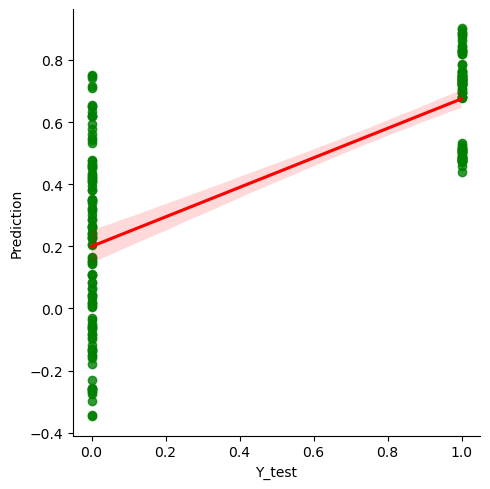

In [33]:
sns.lmplot(
    x='Y_test',
    y='Prediction',
    data=df,
    scatter_kws={'color':'g'},
    line_kws={'color':'r'}
)
plt.show()